# Estimation du nombre optimal de clusters $K$ pour la segmentation par K-means

## Contexte et motivation

L'approche naïve consiste à fixer $K = 2$ (lésion vs. fond). Or, les images dermoscopiques contiennent souvent des **éléments parasites** (poils, bulles d'air, reflets spéculaires, bordures de dermatoscope, règles graduées) qui forment des classes colorimétriques distinctes. Forcer $K = 2$ dans ces cas oblige l'algorithme à absorber ces artefacts dans l'un des deux clusters, faussant la segmentation.

**Problème d'assignation du cluster « lésion ».**
L'analyse exploratoire (cf. `description.ipynb`) a montré que dans **96,1 % des images**, la lésion est plus sombre que le fond. Cette observation justifie l'heuristique « le cluster le plus sombre = lésion » comme règle d'assignation dans le cas $K = 2$. Cependant, dès que $K > 2$, cette heuristique ne suffit plus : il faut décider quels clusters parmi $K$ correspondent à la lésion et lesquels au fond. On utilisera alors l'**hypothèse de centralité** (la lésion occupe majoritairement le centre de l'image, centroïdes moyens $\bar{x} \approx 0.49$, $\bar{y} \approx 0.50$) comme critère d'assignation.

**Objectif de ce notebook** : estimer le $K$ optimal de manière data-driven via trois méthodes complémentaires :

| Méthode | Principe | Critère |
|---------|----------|---------|
| **Elbow** | Décroissance de l'inertie intra-classe | Recherche du « coude » (gain marginal décroissant) |
| **Silhouette** | Qualité de séparation inter/intra-cluster | Maximisation du score moyen $\in [-1, 1]$ |
| **BIC (GMM)** | Sélection de modèle (mélange gaussien) | Minimisation du critère bayésien |

Pour chaque image, on testera $K \in \{2, 3, 4, 5, 6\}$ et on rapportera le $K^\star$ optimal selon chaque critère.

In [1]:
import numpy as np
import warnings
from pathlib import Path
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedShuffleSplit
from scipy import ndimage
import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

# ── Chemins ──
BASE = Path(".").resolve()
IMG_DIR = BASE / "dataset_ISIC" / "ISBI2016_ISIC_Part1_Training_Data"
MASK_DIR = BASE / "dataset_ISIC" / "ISBI2016_ISIC_Part1_Training_GroundTruth"

img_paths = sorted(IMG_DIR.glob("*.jpg"))
mask_paths = sorted(MASK_DIR.glob("*.png"))
N = len(img_paths)
print(f"Images : {N} | Masques : {len(mask_paths)}")

# ── Fonctions utilitaires ──
def load_img(path):
    return np.array(Image.open(path).convert("RGB"))

def load_mask(path):
    m = np.array(Image.open(path).convert("L"))
    return (m > 127).astype(np.uint8)

def subsample_pixels(img, n_samples=10000, seed=42):
    """Sous-échantillonne n_samples pixels (RGB) d'une image pour accélérer les calculs."""
    h, w, c = img.shape
    pixels = img.reshape(-1, c).astype(np.float64)
    rng = np.random.RandomState(seed)
    if len(pixels) > n_samples:
        idx = rng.choice(len(pixels), n_samples, replace=False)
        return pixels[idx]
    return pixels

# ── Métriques de segmentation ──
def dice(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    denom = np.sum(y_true) + np.sum(y_pred)
    return 2.0 * inter / denom if denom > 0 else 1.0

def iou(y_true, y_pred):
    inter = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - inter
    return inter / union if union > 0 else 1.0

def pixel_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def keep_largest_component(mask_binary):
    labeled, n = ndimage.label(mask_binary)
    if n <= 1:
        return mask_binary
    sizes = ndimage.sum(mask_binary, labeled, range(1, n + 1))
    largest = np.argmax(sizes) + 1
    return (labeled == largest).astype(np.uint8)

# ── Split stratifié (même logique que le U-Net) ──
# On calcule le ratio rho pour chaque image et on stratifie dessus
print("Calcul des ratios rho pour le split stratifié...")
rhos = []
for i in range(N):
    gt = load_mask(mask_paths[i])
    rhos.append(np.sum(gt) / gt.size)
rhos = np.array(rhos)

# Discrétiser rho en classes pour la stratification
def rho_to_class(rho):
    if rho < 0.05:
        return 0  # petites
    elif rho < 0.10:
        return 1  # moyennes
    else:
        return 2  # grandes

rho_classes = np.array([rho_to_class(r) for r in rhos])

# Split 75% / 25% stratifié — on ne travaille que sur les 25%
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
idx_rest, idx_eval = next(sss.split(np.zeros(N), rho_classes))

eval_img_paths = [img_paths[i] for i in idx_eval]
eval_mask_paths = [mask_paths[i] for i in idx_eval]
eval_rhos = rhos[idx_eval]
N_eval = len(idx_eval)

print(f"\nSplit stratifié effectué :")
print(f"  Réserve (75%) : {len(idx_rest)} images")
print(f"  Évaluation (25%) : {N_eval} images")
print(f"\nRépartition dans le subset d'évaluation :")
for label, cl in [("Petites (<5%)", 0), ("Moyennes (5-10%)", 1), ("Grandes (>10%)", 2)]:
    n_cl = np.sum(rho_classes[idx_eval] == cl)
    print(f"  {label} : {n_cl} ({100*n_cl/N_eval:.1f}%)")

print("\nSetup terminé.")

Images : 900 | Masques : 900
Calcul des ratios rho pour le split stratifié...

Split stratifié effectué :
  Réserve (75%) : 675 images
  Évaluation (25%) : 225 images

Répartition dans le subset d'évaluation :
  Petites (<5%) : 18 (8.0%)
  Moyennes (5-10%) : 36 (16.0%)
  Grandes (>10%) : 171 (76.0%)

Setup terminé.


## 1. Les trois méthodes d'estimation de $K$

### 1.1 Elbow method (inertie)

L'**inertie** est la somme des distances au carré entre chaque point et le centroïde de son cluster :

$$W_K = \sum_{k=1}^{K} \sum_{\mathbf{z}_i \in C_k} \|\mathbf{z}_i - \boldsymbol{\mu}_k\|^2$$

Elle décroît mécaniquement quand $K$ augmente. Le $K$ optimal se situe au **coude** de la courbe $W_K$ vs $K$ : au-delà, le gain marginal devient négligeable.

### 1.2 Silhouette score

Pour chaque point $i$ :
- $a(i)$ = distance moyenne intra-cluster (cohésion)
- $b(i)$ = distance moyenne au cluster le plus proche (séparation)

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \in [-1, 1]$$

Le score global $\bar{s}$ est la moyenne sur tous les points. On choisit $K^\star = \arg\max_K \bar{s}$.

### 1.3 BIC via GMM (Gaussian Mixture Model)

Le GMM modélise la distribution des pixels comme un mélange de $K$ gaussiennes. Le **BIC** (Bayesian Information Criterion) pénalise la log-vraisemblance par la complexité du modèle :

$$\text{BIC} = -2 \ln \hat{L} + p \ln n$$

où $\hat{L}$ est la vraisemblance maximisée, $p$ le nombre de paramètres et $n$ le nombre d'observations. On choisit $K^\star = \arg\min_K \text{BIC}$.

### Note sur le sous-échantillonnage

Une image de $1024 \times 768 = 786\,432$ pixels rend le calcul du silhouette score ($O(n^2)$) et du GMM prohibitif. On **sous-échantillonne 10 000 pixels** par image (tirage aléatoire uniforme), ce qui est suffisant pour une estimation fiable du $K$ optimal tout en gardant un temps de calcul raisonnable.

In [2]:
# ═══════════════════════════════════════════════════════════════
# Fonctions d'estimation du K optimal
# ═══════════════════════════════════════════════════════════════

K_RANGE = range(2, 7)  # K = 2, 3, 4, 5, 6

def estimate_k_elbow(pixels, k_range=K_RANGE):
    """Retourne les inerties pour chaque K. Le coude est détecté par la plus grande chute relative."""
    inertias = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=5, random_state=42)
        km.fit(pixels)
        inertias.append(km.inertia_)
    
    # Détection automatique du coude : plus grande "cassure" dans la dérivée seconde
    inertias = np.array(inertias)
    if len(inertias) >= 3:
        d1 = np.diff(inertias)         # dérivée première (toujours négative)
        d2 = np.diff(d1)               # dérivée seconde
        best_k = list(k_range)[np.argmax(d2) + 1]  # +1 car diff décale l'index
    else:
        best_k = 2
    return inertias, best_k


def estimate_k_silhouette(pixels, k_range=K_RANGE):
    """Retourne les silhouette scores pour chaque K et le K optimal."""
    scores = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=5, random_state=42)
        labels = km.fit_predict(pixels)
        s = silhouette_score(pixels, labels, sample_size=min(5000, len(pixels)))
        scores.append(s)
    scores = np.array(scores)
    best_k = list(k_range)[np.argmax(scores)]
    return scores, best_k


def estimate_k_bic(pixels, k_range=K_RANGE):
    """Retourne les BIC pour chaque K (GMM) et le K optimal."""
    bics = []
    for k in k_range:
        gmm = GaussianMixture(n_components=k, covariance_type="full",
                               n_init=3, random_state=42)
        gmm.fit(pixels)
        bics.append(gmm.bic(pixels))
    bics = np.array(bics)
    best_k = list(k_range)[np.argmin(bics)]
    return bics, best_k


print(f"K testés : {list(K_RANGE)}")
print("Fonctions d'estimation prêtes.")

K testés : [2, 3, 4, 5, 6]
Fonctions d'estimation prêtes.


## 2. Illustration sur quelques images

Avant de lancer sur tout le dataset, on visualise les 3 courbes (Elbow, Silhouette, BIC) sur 4 images choisies : une facile, une avec artefacts, une avec vignettage, une avec lésion hypopigmentée.

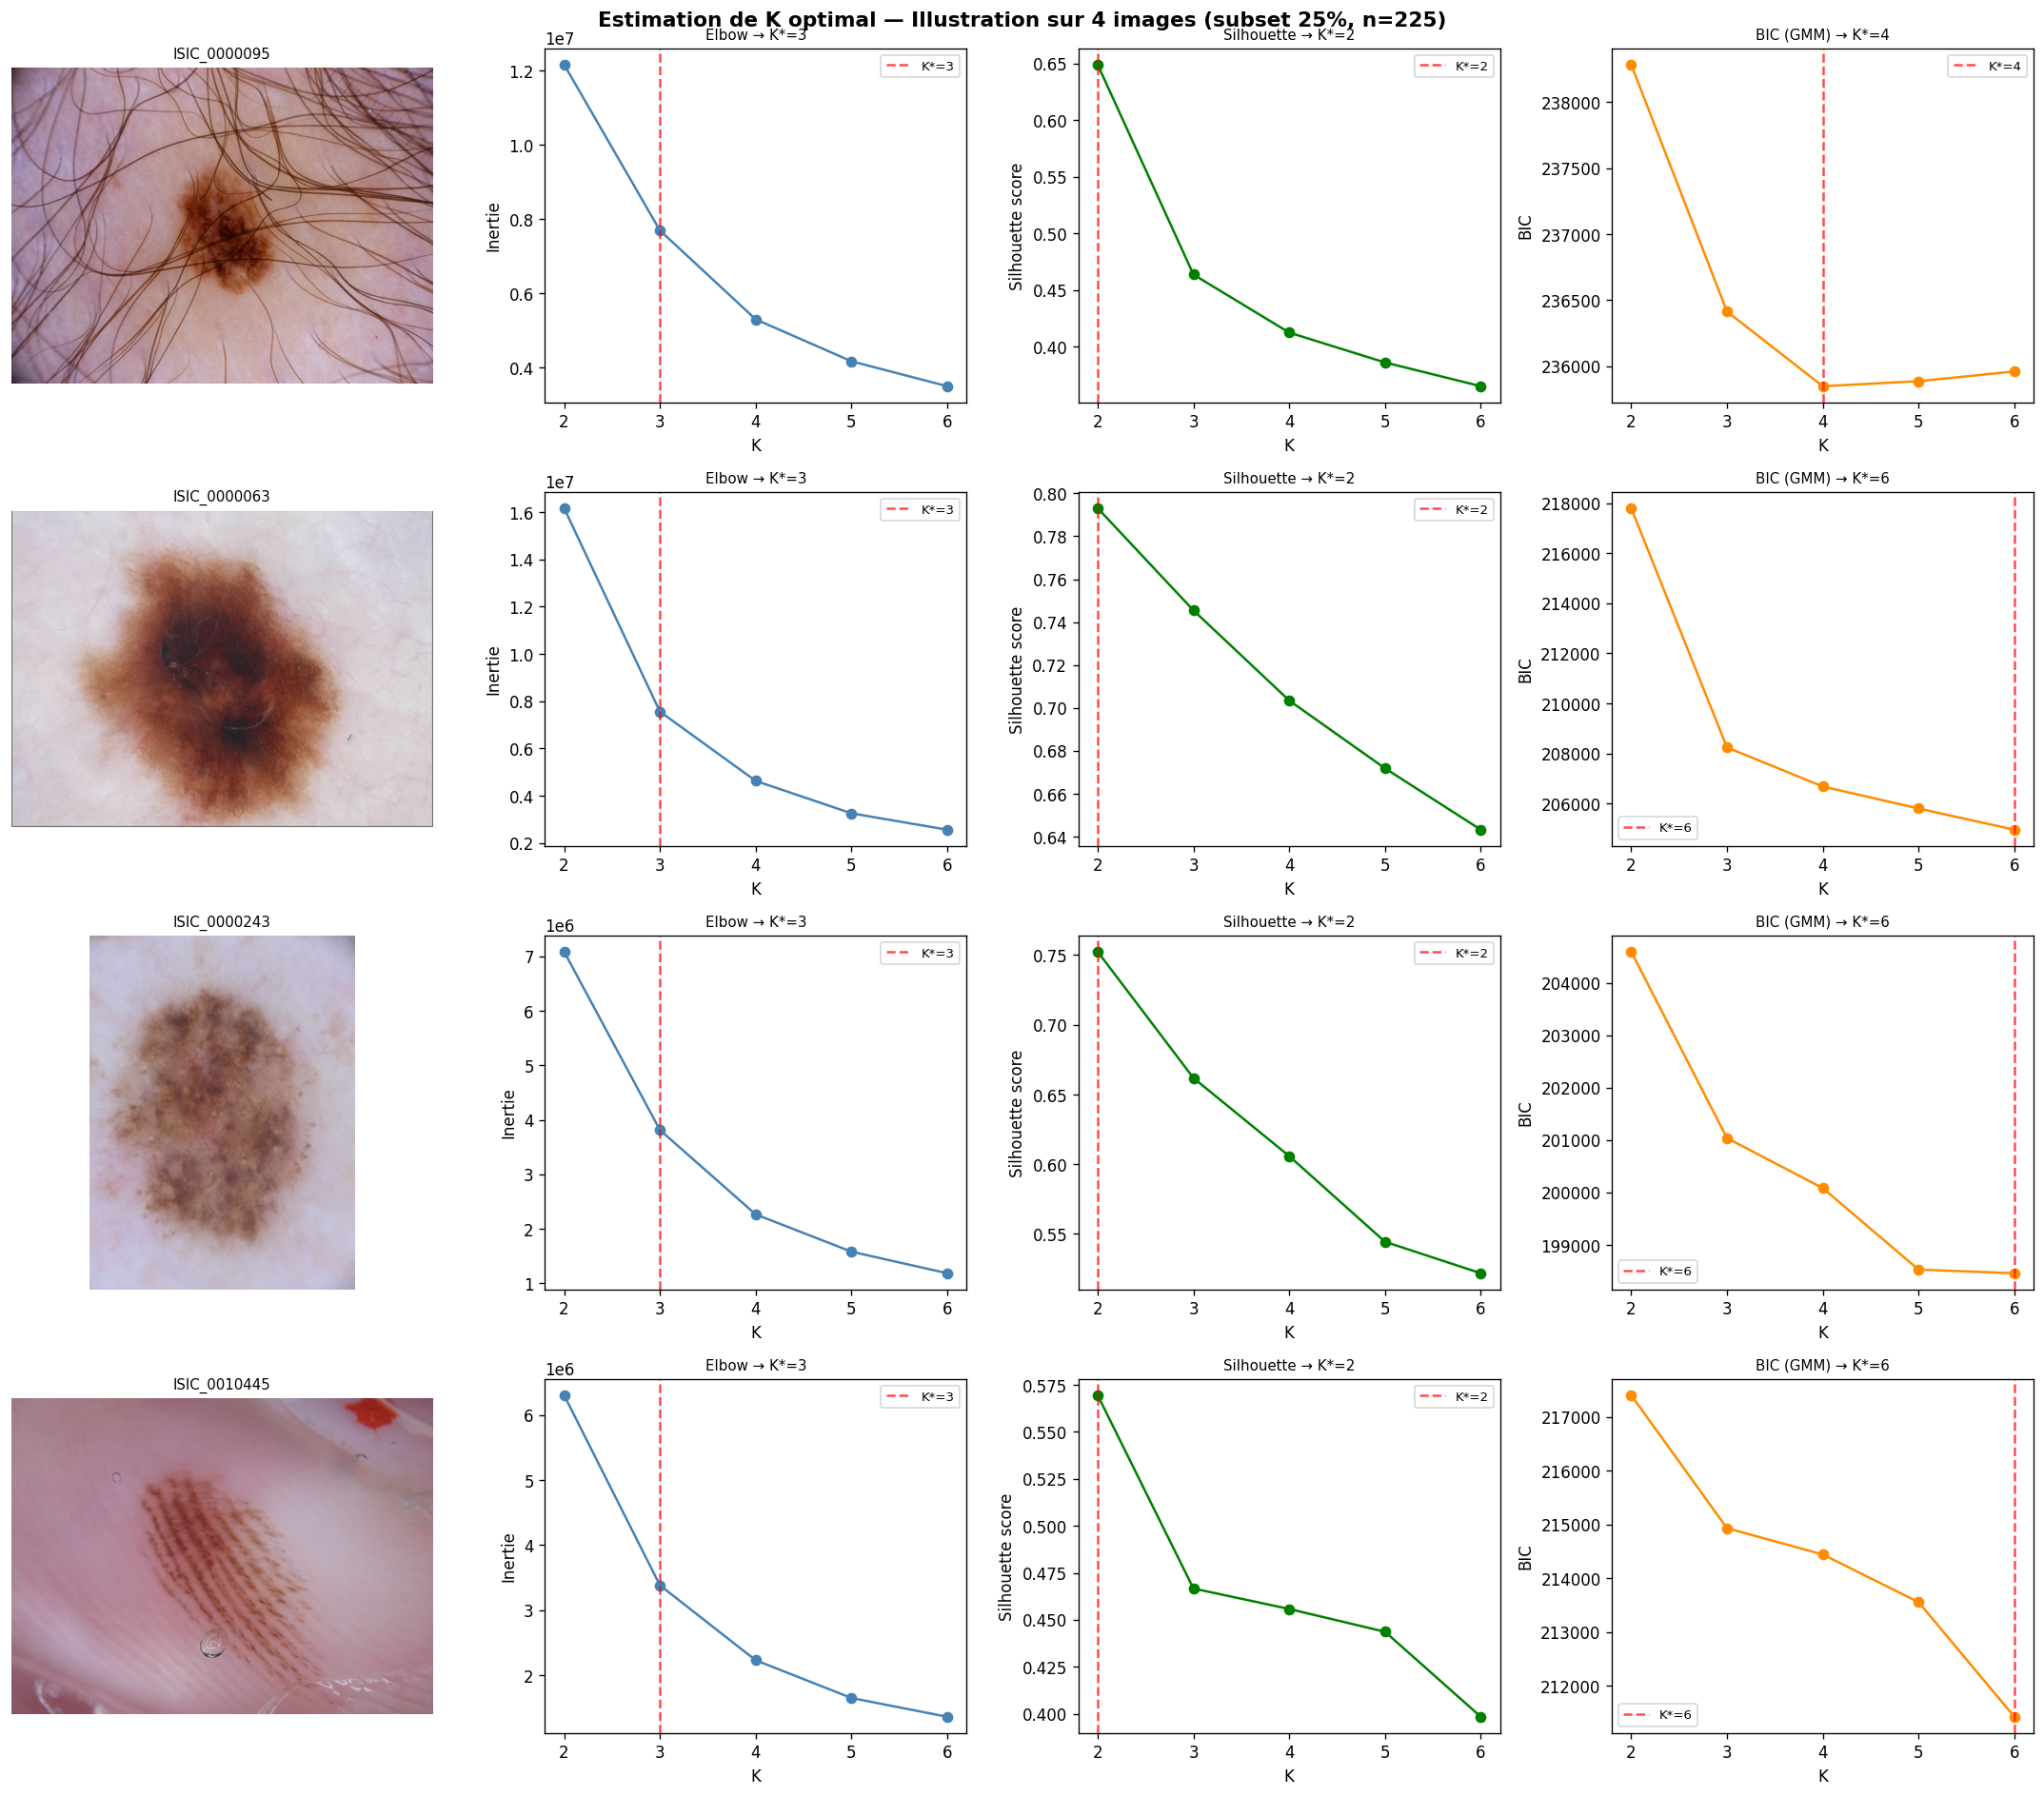

In [3]:
# ═══════════════════════════════════════════════════════════════
# Illustration sur 4 images du subset d'évaluation
# ═══════════════════════════════════════════════════════════════

demo_indices = [0, N_eval // 4, N_eval // 2, 3 * N_eval // 4]
k_list = list(K_RANGE)

fig, axes = plt.subplots(len(demo_indices), 4, figsize=(18, 4 * len(demo_indices)))

for row, idx in enumerate(demo_indices):
    img = load_img(eval_img_paths[idx])
    stem = eval_img_paths[idx].stem
    pixels = subsample_pixels(img, n_samples=10000)
    
    inertias, k_elbow = estimate_k_elbow(pixels)
    sil_scores, k_sil = estimate_k_silhouette(pixels)
    bics, k_bic = estimate_k_bic(pixels)
    
    # Image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{stem}", fontsize=9)
    axes[row, 0].axis("off")
    
    # Elbow
    axes[row, 1].plot(k_list, inertias, "o-", color="steelblue")
    axes[row, 1].axvline(k_elbow, color="red", linestyle="--", alpha=0.7, label=f"K*={k_elbow}")
    axes[row, 1].set_xlabel("K")
    axes[row, 1].set_ylabel("Inertie")
    axes[row, 1].set_title(f"Elbow → K*={k_elbow}", fontsize=9)
    axes[row, 1].legend(fontsize=8)
    
    # Silhouette
    axes[row, 2].plot(k_list, sil_scores, "o-", color="green")
    axes[row, 2].axvline(k_sil, color="red", linestyle="--", alpha=0.7, label=f"K*={k_sil}")
    axes[row, 2].set_xlabel("K")
    axes[row, 2].set_ylabel("Silhouette score")
    axes[row, 2].set_title(f"Silhouette → K*={k_sil}", fontsize=9)
    axes[row, 2].legend(fontsize=8)
    
    # BIC
    axes[row, 3].plot(k_list, bics, "o-", color="darkorange")
    axes[row, 3].axvline(k_bic, color="red", linestyle="--", alpha=0.7, label=f"K*={k_bic}")
    axes[row, 3].set_xlabel("K")
    axes[row, 3].set_ylabel("BIC")
    axes[row, 3].set_title(f"BIC (GMM) → K*={k_bic}", fontsize=9)
    axes[row, 3].legend(fontsize=8)

fig.suptitle(f"Estimation de K optimal — Illustration sur 4 images (subset 25%, n={N_eval})", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 3. Estimation de $K^\star$ sur le subset d'évaluation (25%)

Pour chaque image du subset (≈225 images, stratifié par taille de lésion), on estime le $K$ optimal selon les trois critères. On rapporte ensuite la **distribution des $K^\star$** : si la majorité des images donnent $K^\star = 2$, cela justifie empiriquement le choix de $K = 2$. Si beaucoup donnent $K^\star > 2$, cela motive un $K$ adaptatif.

Si les résultats sont prometteurs, on pourra étendre l'analyse au dataset complet.

In [4]:
# ═══════════════════════════════════════════════════════════════
# Estimation de K* sur le subset d'évaluation (25%)
# ═══════════════════════════════════════════════════════════════

results_k = []

for i in range(N_eval):
    img = load_img(eval_img_paths[i])
    stem = eval_img_paths[i].stem
    pixels = subsample_pixels(img, n_samples=10000)
    
    _, k_elbow = estimate_k_elbow(pixels)
    _, k_sil = estimate_k_silhouette(pixels)
    _, k_bic = estimate_k_bic(pixels)
    
    results_k.append({
        "image": stem,
        "k_elbow": k_elbow,
        "k_silhouette": k_sil,
        "k_bic": k_bic,
        "rho": eval_rhos[i],
    })
    
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{N_eval} images traitées...")

df_k = pd.DataFrame(results_k)
print(f"\nTerminé. {N_eval} images analysées.")

  50/225 images traitées...
  100/225 images traitées...
  150/225 images traitées...
  200/225 images traitées...

Terminé. 225 images analysées.


## 4. Distribution des $K^\star$ — Résultats (subset 25%)

In [5]:
# ═══════════════════════════════════════════════════════════════
# Distribution des K* selon chaque méthode
# ═══════════════════════════════════════════════════════════════

methods_k = ["k_elbow", "k_silhouette", "k_bic"]
method_labels = ["Elbow", "Silhouette", "BIC (GMM)"]

print(f"Distribution des K* optimaux par méthode (n={N_eval}, subset 25%) :")
print("=" * 60)
for col, label in zip(methods_k, method_labels):
    counts = df_k[col].value_counts().sort_index()
    print(f"\n{label} :")
    for k_val, cnt in counts.items():
        bar = "█" * int(cnt / N_eval * 50)
        print(f"  K={k_val} : {cnt:>4d} ({100*cnt/N_eval:5.1f}%)  {bar}")
    print(f"  Mode : K={df_k[col].mode().iloc[0]}   Moyenne : {df_k[col].mean():.2f}")

# Concordance entre méthodes
print("\n" + "=" * 60)
df_k["agree_all"] = (df_k["k_elbow"] == df_k["k_silhouette"]) & (df_k["k_silhouette"] == df_k["k_bic"])
print(f"Concordance des 3 méthodes : {df_k['agree_all'].sum()}/{N_eval} images ({100*df_k['agree_all'].mean():.1f}%)")

df_k["agree_2_is_best"] = (df_k["k_elbow"] == 2) & (df_k["k_silhouette"] == 2) & (df_k["k_bic"] == 2)
print(f"Les 3 méthodes recommandent K=2 : {df_k['agree_2_is_best'].sum()}/{N_eval} images ({100*df_k['agree_2_is_best'].mean():.1f}%)")

Distribution des K* optimaux par méthode (n=225, subset 25%) :

Elbow :
  K=3 :  210 ( 93.3%)  ██████████████████████████████████████████████
  K=4 :   15 (  6.7%)  ███
  Mode : K=3   Moyenne : 3.07

Silhouette :
  K=2 :  203 ( 90.2%)  █████████████████████████████████████████████
  K=3 :   17 (  7.6%)  ███
  K=4 :    5 (  2.2%)  █
  Mode : K=2   Moyenne : 2.12

BIC (GMM) :
  K=4 :    2 (  0.9%)  
  K=5 :   24 ( 10.7%)  █████
  K=6 :  199 ( 88.4%)  ████████████████████████████████████████████
  Mode : K=6   Moyenne : 5.88

Concordance des 3 méthodes : 0/225 images (0.0%)
Les 3 méthodes recommandent K=2 : 0/225 images (0.0%)


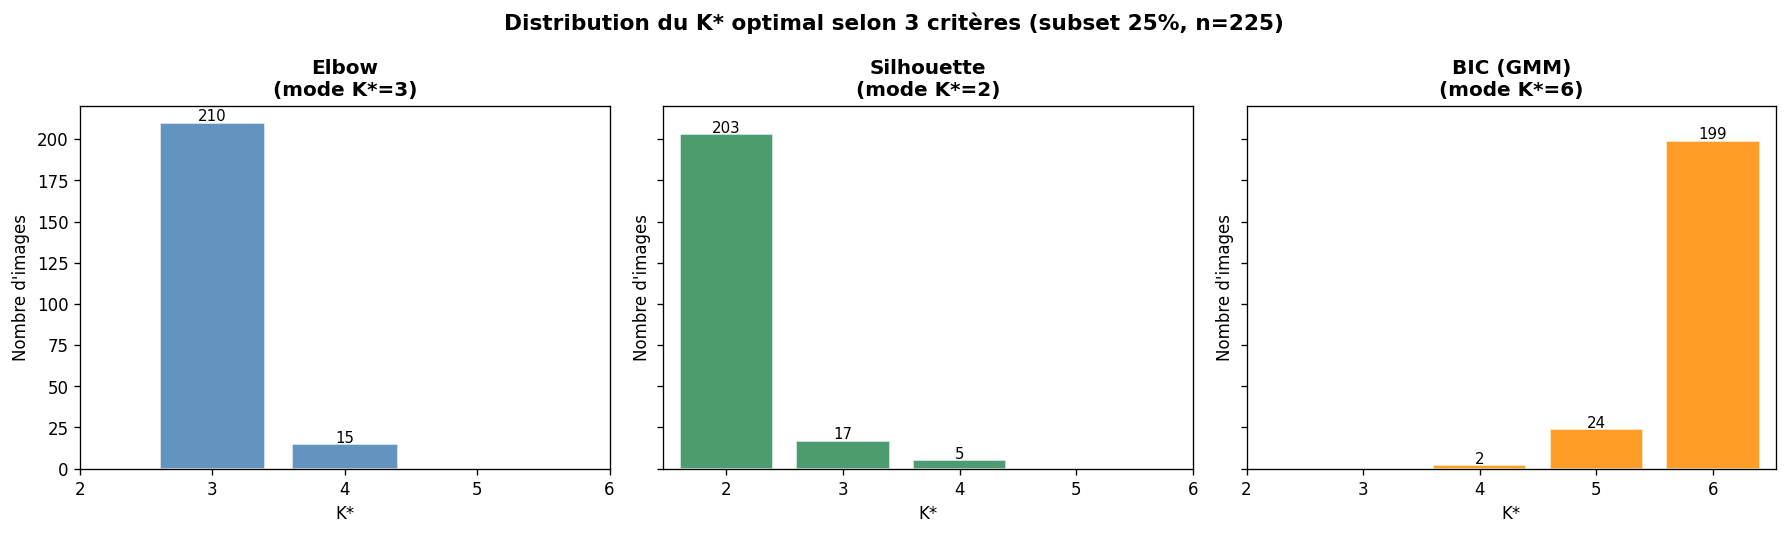

In [6]:
# ═══════════════════════════════════════════════════════════════
# Barplots de la distribution des K*
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
colors = ["steelblue", "seagreen", "darkorange"]

for ax, col, label, c in zip(axes, methods_k, method_labels, colors):
    counts = df_k[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=c, edgecolor="white", alpha=0.85)
    ax.set_xlabel("K*")
    ax.set_ylabel("Nombre d'images")
    ax.set_title(f"{label}\n(mode K*={df_k[col].mode().iloc[0]})", fontweight="bold")
    ax.set_xticks(list(K_RANGE))
    
    # Annoter les barres
    for k_val, cnt in counts.items():
        ax.text(k_val, cnt + 1, f"{cnt}", ha="center", fontsize=9)

fig.suptitle(f"Distribution du K* optimal selon 3 critères (subset 25%, n={N_eval})", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 5. Segmentation : grille complète 2×2 (subset 25%)

On croise **2 choix de K** × **2 règles d'assignation** = **4 configurations**, ce qui permet d'isoler l'effet marginal de chaque facteur :

|  | **Sombre** | **Centralité** |
|--|-----------|---------------|
| **K=2 fixe** | Baseline naïve | Effet de l'assignation seule |
| **K adaptatif** | Effet du K seul | Effet combiné |

In [7]:
# ═══════════════════════════════════════════════════════════════
# Segmentation K-means : 2 règles d'assignation × 2 choix de K = 4 configs
# ═══════════════════════════════════════════════════════════════

def assign_lesion_by_centrality(img_rgb, labels_2d, k):
    """
    Assigne le cluster 'lésion' selon l'hypothèse de centralité :
    le cluster le plus représenté dans la zone centrale est la lésion.
    """
    h, w = labels_2d.shape
    margin_h, margin_w = h // 4, w // 4
    center_labels = labels_2d[margin_h:h-margin_h, margin_w:w-margin_w]
    counts = np.bincount(center_labels.ravel(), minlength=k)
    lesion_cluster = np.argmax(counts)
    mask = (labels_2d == lesion_cluster).astype(np.uint8)
    return keep_largest_component(mask)


def assign_lesion_by_darkness(img_rgb, labels_2d, k):
    """
    Assigne le cluster le plus sombre (en niveaux de gris) à la lésion.
    """
    gray = 0.299 * img_rgb[..., 0] + 0.587 * img_rgb[..., 1] + 0.114 * img_rgb[..., 2]
    mean_gray = [gray[labels_2d == c].mean() for c in range(k)]
    dark_cluster = int(np.argmin(mean_gray))
    mask = (labels_2d == dark_cluster).astype(np.uint8)
    return keep_largest_component(mask)


def segment_kmeans(img, k, assign_fn):
    """K-means générique : K clusters + règle d'assignation au choix."""
    h, w, _ = img.shape
    pixels = img.reshape(-1, 3).astype(np.float64)
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(pixels).reshape(h, w)
    return assign_fn(img, labels, k)


# Les 4 configurations à tester
CONFIGS = {
    "K=2, sombre":              lambda img, k_star: segment_kmeans(img, 2, assign_lesion_by_darkness),
    "K=2, centralité":          lambda img, k_star: segment_kmeans(img, 2, assign_lesion_by_centrality),
    "K adaptatif, sombre":      lambda img, k_star: segment_kmeans(img, k_star, assign_lesion_by_darkness),
    "K adaptatif, centralité":  lambda img, k_star: segment_kmeans(img, k_star, assign_lesion_by_centrality),
}

print(f"4 configurations définies : {list(CONFIGS.keys())}")

4 configurations définies : ['K=2, sombre', 'K=2, centralité', 'K adaptatif, sombre', 'K adaptatif, centralité']


In [8]:
# ═══════════════════════════════════════════════════════════════
# Évaluation : grille 2×2 (K × assignation) sur le subset 25%
# ═══════════════════════════════════════════════════════════════

results_seg = []

for i in range(N_eval):
    img = load_img(eval_img_paths[i])
    gt = load_mask(eval_mask_paths[i])
    stem = eval_img_paths[i].stem
    k_star = int(df_k.iloc[i]["k_silhouette"])
    
    row = {"image": stem, "k_star": k_star, "rho": eval_rhos[i]}
    
    for config_name, config_fn in CONFIGS.items():
        pred = config_fn(img, k_star)
        row[f"dice_{config_name}"] = dice(gt, pred)
        row[f"iou_{config_name}"] = iou(gt, pred)
        row[f"acc_{config_name}"] = pixel_accuracy(gt, pred)
    
    results_seg.append(row)
    
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{N_eval} images traitées...")

df_seg = pd.DataFrame(results_seg)
print(f"\nTerminé. {N_eval} images × 4 configurations = {N_eval * 4} segmentations.")

  50/225 images traitées...
  100/225 images traitées...
  150/225 images traitées...
  200/225 images traitées...

Terminé. 225 images × 4 configurations = 900 segmentations.


## 6. Résultats comparatifs — Grille 2×2 (subset 25%)

In [9]:
# ═══════════════════════════════════════════════════════════════
# Tableau comparatif — 4 configurations
# ═══════════════════════════════════════════════════════════════

config_names = list(CONFIGS.keys())

print("=" * 100)
print(f"{'Configuration':<30} {'DSC mean±std':>18} {'IoU mean±std':>18} {'Acc mean±std':>18} {'Échecs':>8}")
print("=" * 100)

for cn in config_names:
    d = df_seg[f"dice_{cn}"]
    j = df_seg[f"iou_{cn}"]
    a = df_seg[f"acc_{cn}"]
    n_fail = (d < 0.5).sum()
    print(f"{cn:<30} {d.mean():.3f} ± {d.std():.3f}   "
          f"{j.mean():.3f} ± {j.std():.3f}   "
          f"{a.mean():.3f} ± {a.std():.3f}   "
          f"{n_fail:>3d}")

print("=" * 100)

# Décomposition des effets
baseline = df_seg["dice_K=2, sombre"]
effect_assign = df_seg["dice_K=2, centralité"] - baseline
effect_k = df_seg["dice_K adaptatif, sombre"] - baseline
effect_both = df_seg["dice_K adaptatif, centralité"] - baseline

print(f"\nDécomposition des effets (ΔDSC moyen vs baseline) :")
print(f"  Effet assignation seule (K=2 centralité - K=2 sombre) :  {effect_assign.mean():+.4f}")
print(f"  Effet K adaptatif seul  (K* sombre - K=2 sombre) :       {effect_k.mean():+.4f}")
print(f"  Effet combiné           (K* centralité - K=2 sombre) :   {effect_both.mean():+.4f}")

Configuration                        DSC mean±std       IoU mean±std       Acc mean±std   Échecs
K=2, sombre                    0.576 ± 0.357   0.484 ± 0.324   0.823 ± 0.159    69
K=2, centralité                0.463 ± 0.353   0.375 ± 0.325   0.527 ± 0.343   114
K adaptatif, sombre            0.570 ± 0.355   0.478 ± 0.323   0.823 ± 0.168    72
K adaptatif, centralité        0.458 ± 0.351   0.370 ± 0.324   0.526 ± 0.340   116

Décomposition des effets (ΔDSC moyen vs baseline) :
  Effet assignation seule (K=2 centralité - K=2 sombre) :  -0.1132
  Effet K adaptatif seul  (K* sombre - K=2 sombre) :       -0.0059
  Effet combiné           (K* centralité - K=2 sombre) :   -0.1177


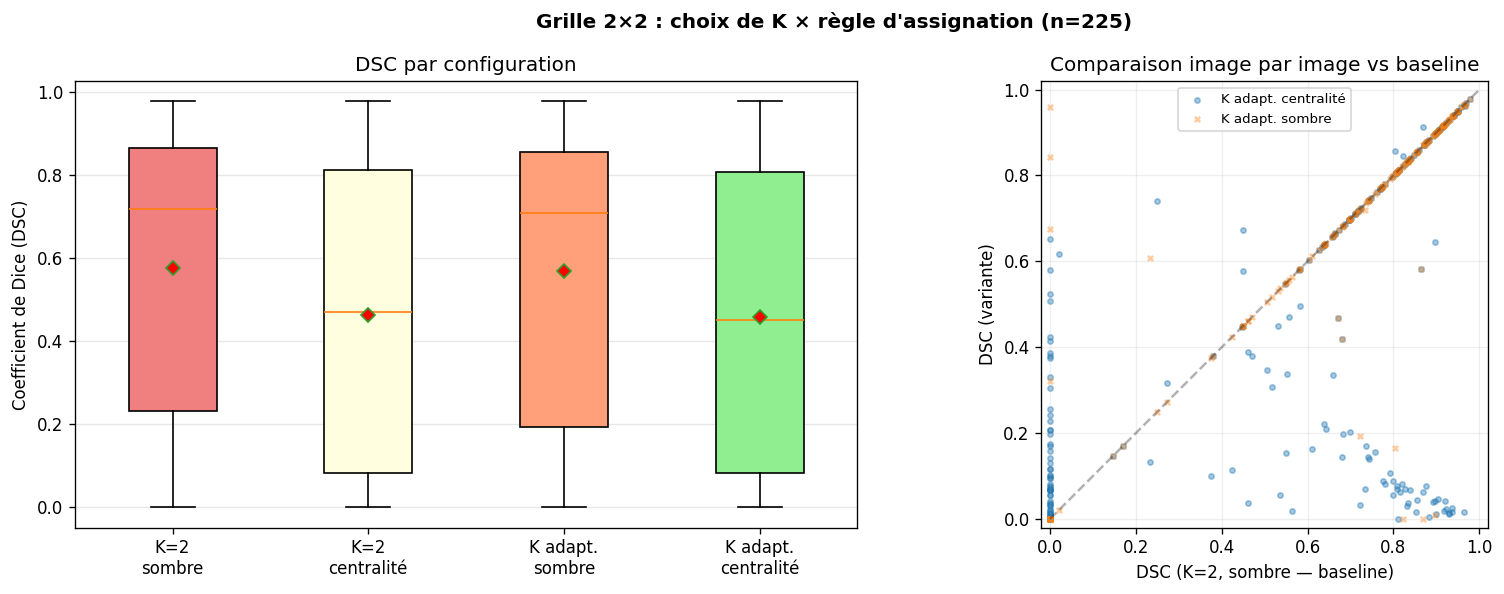

In [10]:
# ═══════════════════════════════════════════════════════════════
# Boxplots comparatifs — 4 configurations
# ═══════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot DSC des 4 configs
data_dice = [df_seg[f"dice_{cn}"] for cn in config_names]
short_labels = ["K=2\nsombre", "K=2\ncentralité", "K adapt.\nsombre", "K adapt.\ncentralité"]
bp1 = ax1.boxplot(data_dice, labels=short_labels, patch_artist=True, showmeans=True,
                   meanprops=dict(marker="D", markerfacecolor="red", markersize=6))
box_colors = ["lightcoral", "lightyellow", "lightsalmon", "lightgreen"]
for patch, c in zip(bp1["boxes"], box_colors):
    patch.set_facecolor(c)
ax1.set_ylabel("Coefficient de Dice (DSC)")
ax1.set_title("DSC par configuration")
ax1.grid(axis="y", alpha=0.3)

# Scatter : baseline vs meilleure config
ax2.scatter(df_seg["dice_K=2, sombre"], df_seg["dice_K adaptatif, centralité"],
            s=10, alpha=0.4, label="K adapt. centralité")
ax2.scatter(df_seg["dice_K=2, sombre"], df_seg["dice_K adaptatif, sombre"],
            s=10, alpha=0.4, label="K adapt. sombre", marker="x")
ax2.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax2.set_xlabel("DSC (K=2, sombre — baseline)")
ax2.set_ylabel("DSC (variante)")
ax2.set_title("Comparaison image par image vs baseline")
ax2.set_xlim(-0.02, 1.02)
ax2.set_ylim(-0.02, 1.02)
ax2.set_aspect("equal")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.2)

fig.suptitle(f"Grille 2×2 : choix de K × règle d'assignation (n={N_eval})", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

## 7. Visualisation : cas où le K adaptatif fait la différence

On identifie les images où le K adaptatif améliore ou dégrade le plus le DSC par rapport à K=2 fixe.

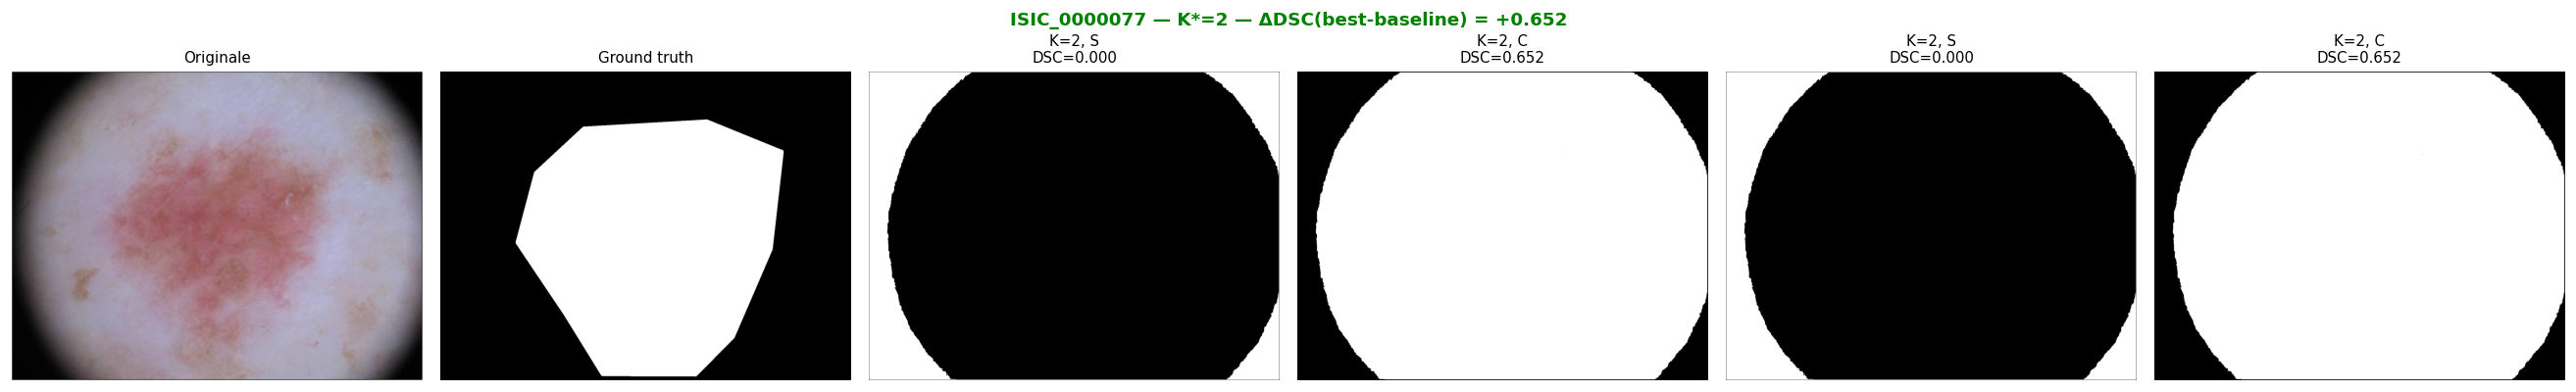

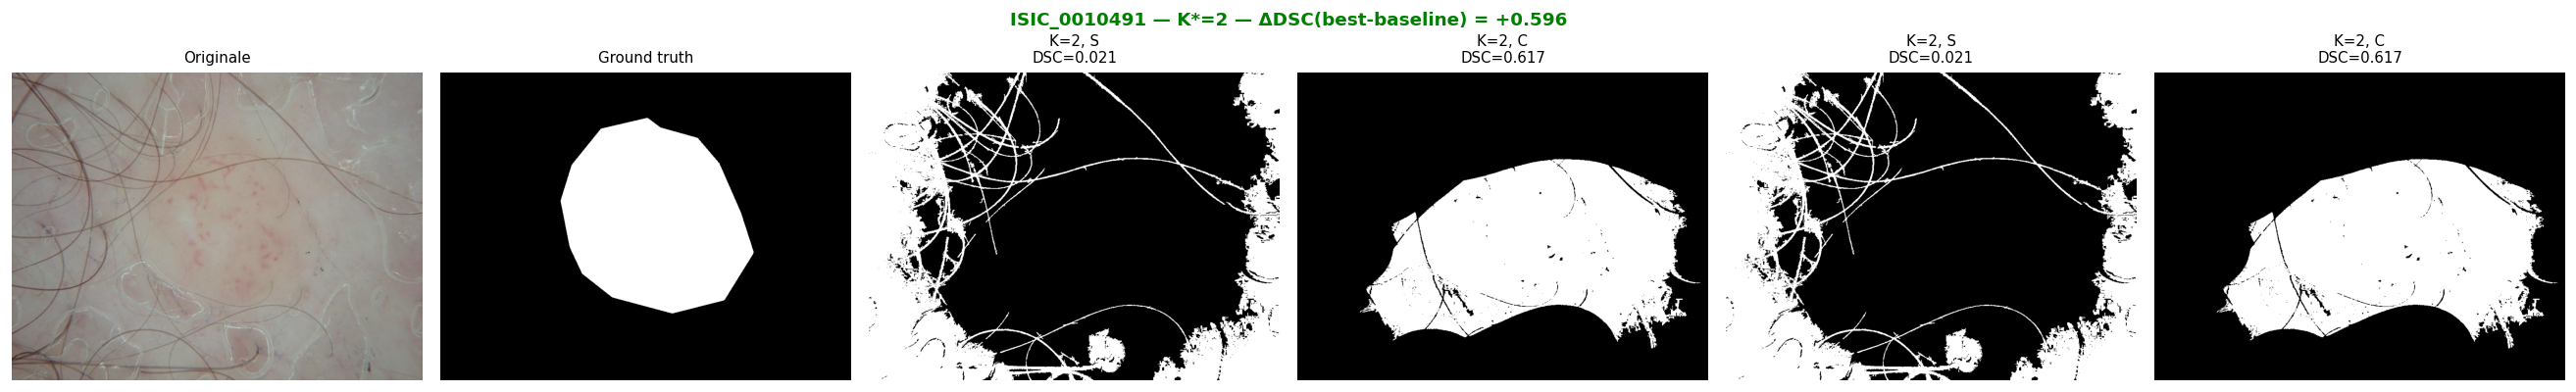

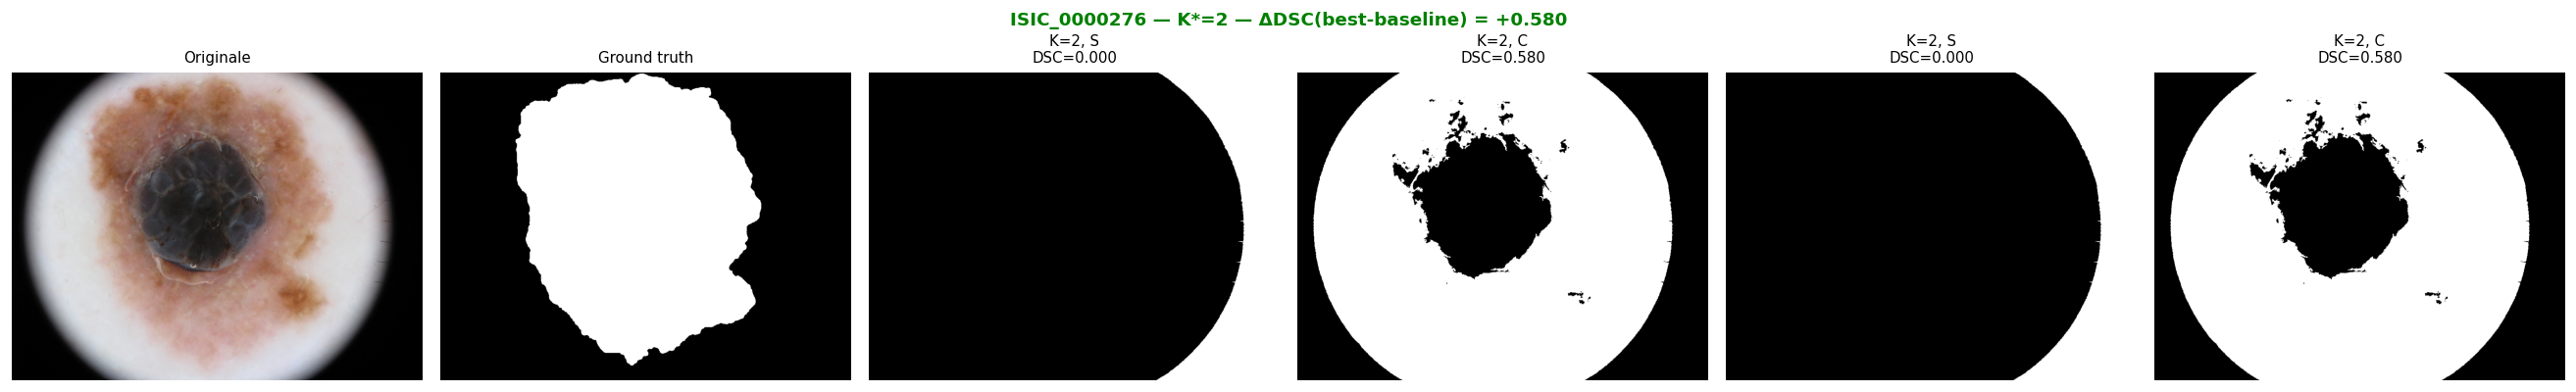

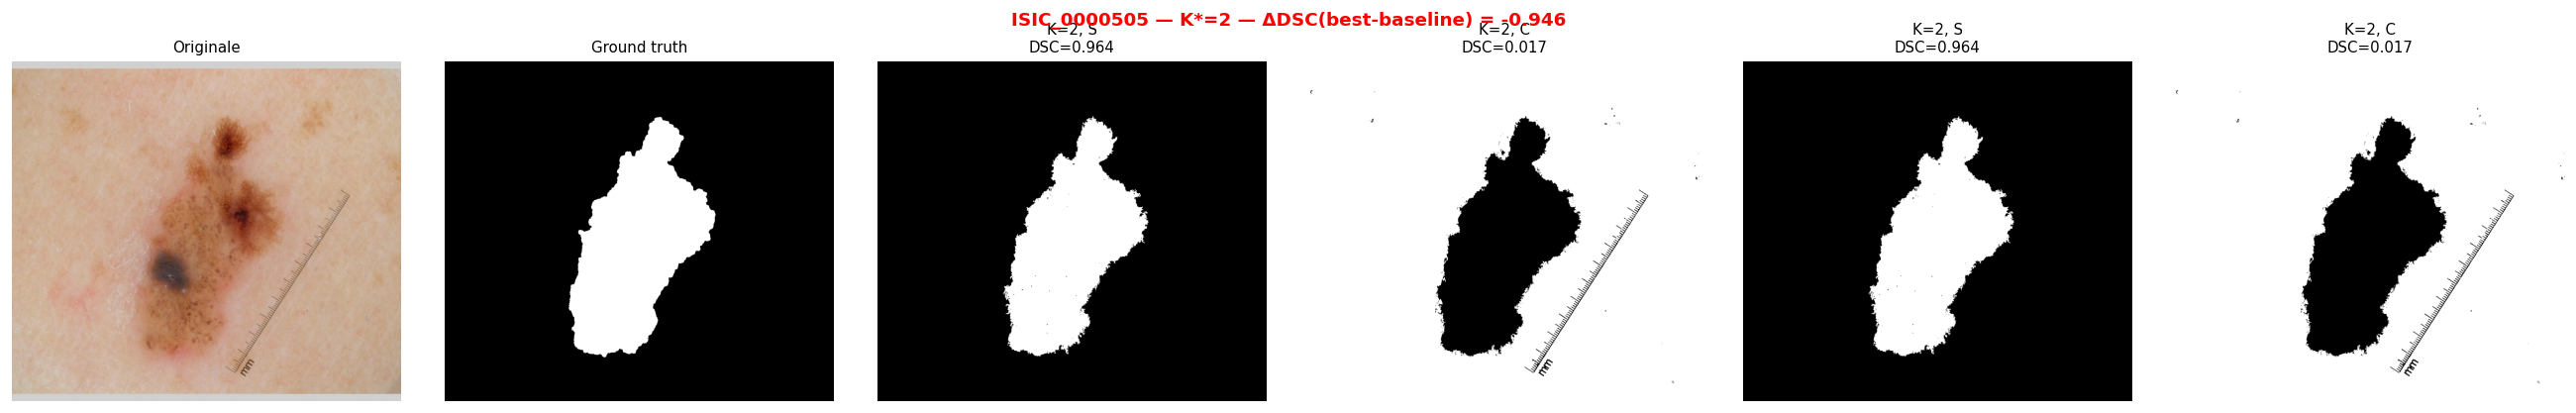

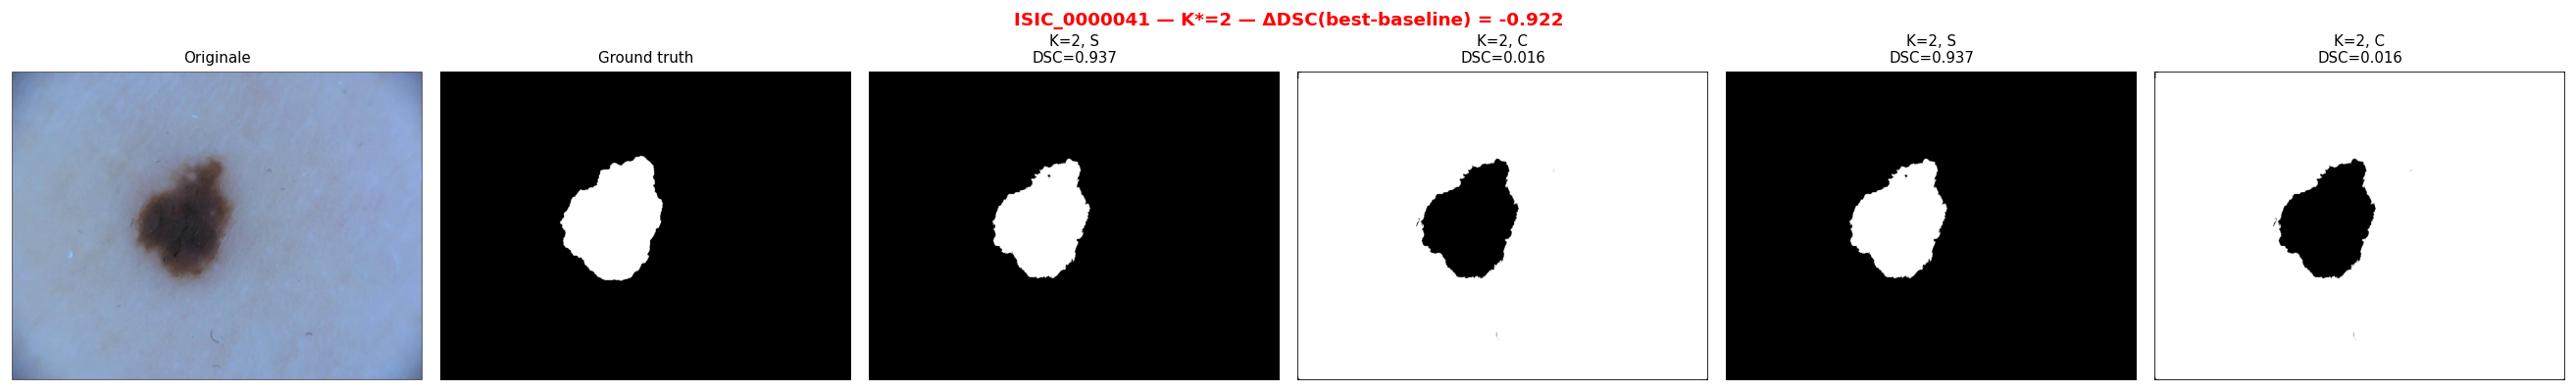

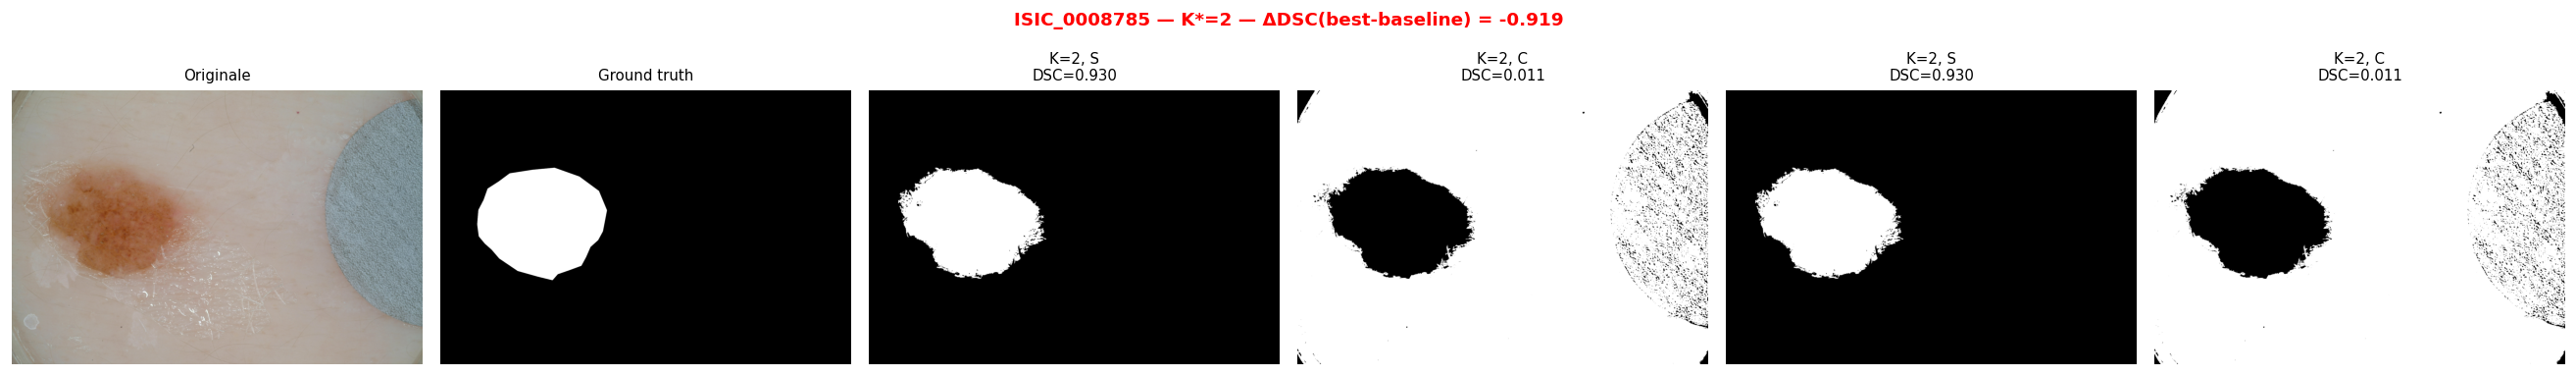

S = sombre, C = centralité


In [11]:
# ═══════════════════════════════════════════════════════════════
# Visualisation des cas extrêmes — baseline vs 3 autres configs
# ═══════════════════════════════════════════════════════════════

# Delta entre la meilleure config (K adaptatif centralité) et la baseline
df_seg["delta_best"] = df_seg["dice_K adaptatif, centralité"] - df_seg["dice_K=2, sombre"]

top_improve = df_seg.nlargest(3, "delta_best")
top_degrade = df_seg.nsmallest(3, "delta_best")
cases = list(top_improve.iterrows()) + list(top_degrade.iterrows())

for _, row in cases:
    idx = next(j for j, p in enumerate(eval_img_paths) if p.stem == row["image"])
    img = load_img(eval_img_paths[idx])
    gt = load_mask(eval_mask_paths[idx])
    k_star = int(row["k_star"])
    
    preds = {}
    for cn, cfn in CONFIGS.items():
        preds[cn] = cfn(img, k_star)
    
    fig, axes = plt.subplots(1, 6, figsize=(22, 3.5))
    
    axes[0].imshow(img)
    axes[0].set_title("Originale", fontsize=9)
    
    axes[1].imshow(gt, cmap="gray")
    axes[1].set_title("Ground truth", fontsize=9)
    
    for j, cn in enumerate(config_names):
        d = row[f"dice_{cn}"]
        axes[j + 2].imshow(preds[cn], cmap="gray")
        k_label = "K=2" if "K=2" in cn else f"K={k_star}"
        axes[j + 2].set_title(f"{k_label}, {'S' if 'sombre' in cn else 'C'}\nDSC={d:.3f}", fontsize=9)
    
    for ax in axes:
        ax.axis("off")
    
    delta = row["delta_best"]
    clr = "green" if delta > 0 else "red"
    fig.suptitle(f"{row['image']} — K*={k_star} — ΔDSC(best-baseline) = {delta:+.3f}",
                 fontsize=11, fontweight="bold", color=clr)
    fig.tight_layout()
    plt.show()

print("S = sombre, C = centralité")

## 8. Tableau LaTeX pour le mémoire

In [12]:
# ═══════════════════════════════════════════════════════════════
# Tableaux LaTeX
# ═══════════════════════════════════════════════════════════════

# Tableau 1 : Distribution des K*
print("% ── Tableau LaTeX : Distribution des K* optimaux ──")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Distribution du nombre optimal de clusters $K^\star$ selon trois critères ($n = " + str(N_eval) + r"$, subset 25\%).}")
print(r"\label{tab:k_optimal}")
print(r"\begin{tabular}{c r r r}")
print(r"\toprule")
print(r"$K^\star$ & \textbf{Elbow} & \textbf{Silhouette} & \textbf{BIC (GMM)} \\")
print(r"\midrule")

for k_val in K_RANGE:
    c_elbow = (df_k["k_elbow"] == k_val).sum()
    c_sil = (df_k["k_silhouette"] == k_val).sum()
    c_bic = (df_k["k_bic"] == k_val).sum()
    print(f"{k_val} & {c_elbow} ({100*c_elbow/N_eval:.1f}\\%) & {c_sil} ({100*c_sil/N_eval:.1f}\\%) & {c_bic} ({100*c_bic/N_eval:.1f}\\%) \\\\")

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")

# Tableau 2 : Grille 2×2
print("\n\n% ── Tableau LaTeX : Grille 2×2 (K × assignation) ──")
print(r"\begin{table}[H]")
print(r"\centering")
print(r"\caption{Grille d'ablation : choix de $K$ $\times$ règle d'assignation ($n = " + str(N_eval) + r"$).}")
print(r"\label{tab:k_grid}")
print(r"\begin{tabular}{l r r r r}")
print(r"\toprule")
print(r"\textbf{Configuration} & \textbf{DSC} & \textbf{IoU} & \textbf{Accuracy} & \textbf{Échecs} \\")
print(r"\midrule")

for cn in config_names:
    d = df_seg[f"dice_{cn}"]
    j = df_seg[f"iou_{cn}"]
    a = df_seg[f"acc_{cn}"]
    n_fail = int((d < 0.5).sum())
    print(f"{cn} & ${d.mean():.3f} \\pm {d.std():.3f}$ & "
          f"${j.mean():.3f} \\pm {j.std():.3f}$ & "
          f"${a.mean():.3f} \\pm {a.std():.3f}$ & "
          f"{n_fail} \\\\")

print(r"\bottomrule")
print(r"\end{tabular}")
print(r"\end{table}")

% ── Tableau LaTeX : Distribution des K* optimaux ──
\begin{table}[H]
\centering
\caption{Distribution du nombre optimal de clusters $K^\star$ selon trois critères ($n = 225$, subset 25\%).}
\label{tab:k_optimal}
\begin{tabular}{c r r r}
\toprule
$K^\star$ & \textbf{Elbow} & \textbf{Silhouette} & \textbf{BIC (GMM)} \\
\midrule
2 & 0 (0.0\%) & 203 (90.2\%) & 0 (0.0\%) \\
3 & 210 (93.3\%) & 17 (7.6\%) & 0 (0.0\%) \\
4 & 15 (6.7\%) & 5 (2.2\%) & 2 (0.9\%) \\
5 & 0 (0.0\%) & 0 (0.0\%) & 24 (10.7\%) \\
6 & 0 (0.0\%) & 0 (0.0\%) & 199 (88.4\%) \\
\bottomrule
\end{tabular}
\end{table}


% ── Tableau LaTeX : Grille 2×2 (K × assignation) ──
\begin{table}[H]
\centering
\caption{Grille d'ablation : choix de $K$ $\times$ règle d'assignation ($n = 225$).}
\label{tab:k_grid}
\begin{tabular}{l r r r r}
\toprule
\textbf{Configuration} & \textbf{DSC} & \textbf{IoU} & \textbf{Accuracy} & \textbf{Échecs} \\
\midrule
K=2, sombre & $0.576 \pm 0.357$ & $0.484 \pm 0.324$ & $0.823 \pm 0.159$ & 69 \\
K=2, cent

## 9. Sauvegarde des résultats

In [13]:
# ═══════════════════════════════════════════════════════════════
# Sauvegarde
# ═══════════════════════════════════════════════════════════════

import json

output = {
    "k_estimation": df_k.to_dict(orient="records"),
    "segmentation_comparison": df_seg.to_dict(orient="records"),
}

# Convertir types numpy
def convert_numpy(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    elif isinstance(obj, (np.floating,)):
        return float(obj)
    elif isinstance(obj, (np.bool_,)):
        return bool(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

out_path = BASE / "results_kmeans_optimal_k.json"
with open(out_path, "w") as f:
    json.dump(output, f, indent=2, ensure_ascii=False, default=convert_numpy)

print(f"Résultats sauvegardés dans : {out_path}")
print(f"Taille : {out_path.stat().st_size / 1024:.0f} Ko")

Résultats sauvegardés dans : /Users/sfarmehdi/Stat_app/statapp/results_kmeans_optimal_k.json
Taille : 206 Ko
